# Deep Learning Wine Regression (Alcohol Prediction)

이 노트북은 `wine.csv` 데이터의 여러 특성을 바탕으로 와인의 알코올 도수(`Alcohol`)를 예측하는 회귀 모델을 구현합니다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [5]:
# 1. 데이터 로드
# 사용자의 요청에 따라 'csv/wine.csv' 경로를 사용합니다.
df = pd.read_csv('csv/wine.csv')
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [6]:
# 2. 데이터 전처리 (회귀용)
# 목표(y): 'Alcohol' (연속적인 수치)
# 피처(X): 'Alcohol'을 제외한 모든 컬럼
X = df.drop('Alcohol', axis=1)
y = df['Alcohol']

# 피처 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0
)

In [7]:
# 3. 모델 구축 (회귀 모델)
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1) # [회귀 핵심] 출력 노드는 1개, 활성화 함수 없음
])

# 4. 모델 컴파일
model.compile(
    optimizer="adam",
    loss="mse",      # [회귀 핵심] 손실 함수로 MSE 사용
    metrics=["mae"]  # 평가 지표로 MAE 사용
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 5. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - loss: 163.2095 - mae: 12.7564 - val_loss: 152.1294 - val_mae: 12.3103
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 147.1812 - mae: 12.1161 - val_loss: 138.8880 - val_mae: 11.7642
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 132.5010 - mae: 11.4954 - val_loss: 125.8847 - val_mae: 11.1985
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 118.3302 - mae: 10.8584 - val_loss: 112.8821 - val_mae: 10.5983
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 103.2125 - mae: 10.1213 - val_loss: 99.1346 - val_mae: 9.9168
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 88.1408 - mae: 9.3221 - val_loss: 84.6896 - val_mae: 9.1338
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 72.6600 - mae: 8.4110 - val_loss: 70.2125 - val_mae: 8.2641
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 57.6482 - mae: 7.4060 - val_loss: 55.9155 - val_mae: 7.2923
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 

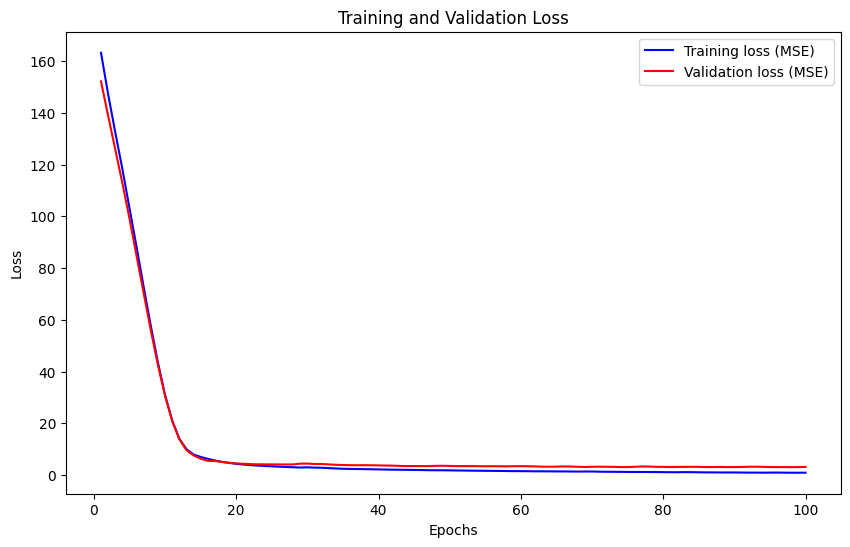

In [9]:
# 6. 학습 곡선 시각화
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'b', label='Training loss (MSE)')
plt.plot(epochs, val_loss, 'r', label='Validation loss (MSE)')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [10]:
# 7. 예측 및 성능 평가
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 301ms/step
Mean Squared Error (MSE): 2.7714
Mean Absolute Error (MAE): 1.2332
R2 Score: -3.0535


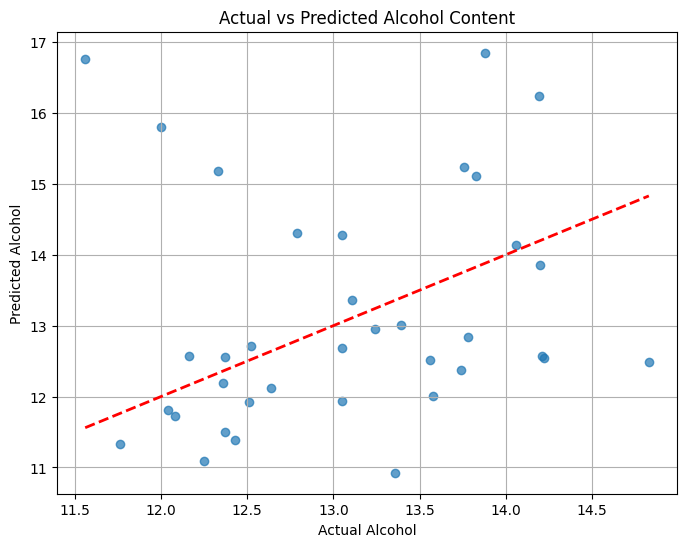

In [11]:
# 8. 실제값 vs 예측값 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Alcohol')
plt.ylabel('Predicted Alcohol')
plt.title('Actual vs Predicted Alcohol Content')
plt.grid(True)
plt.show()